In [1]:
#!/usr/bin/env python
# coding: utf-8

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:

# ============================================================
# 0) Config (the ONLY place you should tweak assumptions)
# ============================================================

CSV_PATH = "../processed/cfsr_storms_labeled_k2.csv"

TYPE1 = "Type 1 (early-life-cycle)"
TYPE2 = "Type 2 (late-life-cycle)"

# Cluster -> type mapping (EDIT HERE if you relabel)
CLUSTER_TO_TYPE = {
    0: TYPE2,
    1: TYPE1,
}

LAKE_ORDER  = ["sup", "mi", "huron", "erie", "ont"]
LAKE_LABELS = {"sup": "Superior", "mi": "Michigan", "huron": "Huron", "erie": "Erie", "ont": "Ontario"}

SEASON_ORDER  = ["DJF", "MAM", "JJA", "SON"]
SEASON_TITLES = {"DJF": "Winter (DJF)", "MAM": "Spring (MAM)", "JJA": "Summer (JJA)", "SON": "Fall (SON)"}

# Impacts + tails for defining extremes
PRECIP_Q = 0.95   # upper tail
EVAP_Q   = 0.05   # lower tail (more negative anomalies)

PRECIP_COLS = [f"{lk}_ttl_precip" for lk in LAKE_ORDER]
EVAP_COLS   = [f"{lk}_ttl_evap_anom" for lk in LAKE_ORDER]

# Bootstrap config
N_BOOT = 2000
SEED = 42
MIN_EVENTS_PER_TYPE = 30


In [3]:


# ============================================================
# 1) Load + minimal derived columns (storm_type, season)
# ============================================================

def add_storm_type(df: pd.DataFrame, cluster_col="k2_cluster") -> pd.DataFrame:
    d = df.copy()
    d["storm_type"] = d[cluster_col].map(CLUSTER_TO_TYPE)
    return d

def add_season_from_month(df: pd.DataFrame, month_col="month", out_col="season") -> pd.DataFrame:
    d = df.copy()
    m = pd.to_numeric(d[month_col], errors="coerce").astype("Int64")

    season = pd.Series(pd.NA, index=d.index, dtype="object")
    season = season.mask(m.isin([12, 1, 2]), "DJF")
    season = season.mask(m.isin([3, 4, 5]), "MAM")
    season = season.mask(m.isin([6, 7, 8]), "JJA")
    season = season.mask(m.isin([9, 10, 11]), "SON")

    d[out_col] = season
    return d


df = pd.read_csv(CSV_PATH)

# sanity
assert "k2_cluster" in df.columns
assert "month" in df.columns  # you said you have it already
df = add_storm_type(df)

# Use existing season if present; otherwise compute from month
if "season" not in df.columns:
    df = add_season_from_month(df)
df["season"] = df["season"].astype(str)

# quick sanity
print(df["storm_type"].value_counts(dropna=False))
print(df["season"].value_counts(dropna=False))


storm_type
Type 1 (early-life-cycle)    1903
Type 2 (late-life-cycle)     1413
Name: count, dtype: int64
season
DJF    1052
MAM     963
SON     807
JJA     494
Name: count, dtype: int64


In [4]:


# ============================================================
# 2) Define extremes (adds *_extreme boolean columns)
# ============================================================

def make_extreme_flags(df: pd.DataFrame, cols: list[str], q: float, tail: str) -> tuple[pd.DataFrame, dict]:
    if tail not in {"upper", "lower"}:
        raise ValueError("tail must be 'upper' or 'lower'")
    d = df.copy()
    thresh = {c: d[c].quantile(q) for c in cols}
    for c in cols:
        outcol = f"{c}_extreme"
        if tail == "upper":
            d[outcol] = d[c] >= thresh[c]
        else:
            d[outcol] = d[c] <= thresh[c]
    return d, thresh

df, precip_thresh = make_extreme_flags(df, PRECIP_COLS, q=PRECIP_Q, tail="upper")
df, evap_thresh   = make_extreme_flags(df, EVAP_COLS,   q=EVAP_Q,   tail="lower")

precip_extreme = {lk: f"{lk}_ttl_precip_extreme" for lk in LAKE_ORDER}
evap_extreme   = {lk: f"{lk}_ttl_evap_anom_extreme" for lk in LAKE_ORDER}


In [5]:


# ============================================================
# 3) Core stats: RR/RD + stratified bootstrap
# ============================================================

def rr_rd_from_probs(p1: float, p2: float) -> tuple[float, float]:
    rr = np.nan if (not np.isfinite(p2) or p2 <= 0) else (p1 / p2)
    rd = p2 - p1  # RD = P2 − P1
    return rr, rd

def bootstrap_rr_rd(
    d: pd.DataFrame,
    extreme_col: str,
    n_boot: int = N_BOOT,
    seed: int = SEED,
    min_events_per_type: int = MIN_EVENTS_PER_TYPE,
) -> dict:
    counts = d["storm_type"].value_counts()
    if (TYPE1 not in counts.index) or (TYPE2 not in counts.index):
        return {"rr_low": np.nan, "rr_median": np.nan, "rr_high": np.nan,
                "rd_low": np.nan, "rd_median": np.nan, "rd_high": np.nan,
                "n_rr_valid": 0, "n_rd_valid": 0}

    if (counts[TYPE1] < min_events_per_type) or (counts[TYPE2] < min_events_per_type):
        return {"rr_low": np.nan, "rr_median": np.nan, "rr_high": np.nan,
                "rd_low": np.nan, "rd_median": np.nan, "rd_high": np.nan,
                "n_rr_valid": 0, "n_rd_valid": 0}

    rng = np.random.default_rng(seed)
    rr_vals, rd_vals = [], []

    a1 = d.loc[d["storm_type"] == TYPE1, extreme_col].to_numpy()
    a2 = d.loc[d["storm_type"] == TYPE2, extreme_col].to_numpy()

    for _ in range(n_boot):
        p1 = float(rng.choice(a1, size=len(a1), replace=True).mean())
        p2 = float(rng.choice(a2, size=len(a2), replace=True).mean())
        rr, rd = rr_rd_from_probs(p1, p2)
        rd_vals.append(rd)
        if np.isfinite(rr):
            rr_vals.append(rr)

    rr_ci = np.percentile(rr_vals, [2.5, 50, 97.5]) if rr_vals else [np.nan, np.nan, np.nan]
    rd_ci = np.percentile(rd_vals, [2.5, 50, 97.5]) if rd_vals else [np.nan, np.nan, np.nan]

    return {
        "rr_low": rr_ci[0], "rr_median": rr_ci[1], "rr_high": rr_ci[2],
        "rd_low": rd_ci[0], "rd_median": rd_ci[1], "rd_high": rd_ci[2],
        "n_rr_valid": len(rr_vals), "n_rd_valid": len(rd_vals),
    }

def build_rr_df(df: pd.DataFrame, lake_to_extreme: dict[str, str], impact: str, season: str | None = None) -> pd.DataFrame:
    base = df if season is None else df[df["season"] == season]
    rows = []
    for lake, extreme_col in lake_to_extreme.items():
        stats = bootstrap_rr_rd(base, extreme_col)
        row = {"lake": lake, "impact": impact, **stats}
        if season is not None:
            row["season"] = season
        rows.append(row)
    out = pd.DataFrame(rows)
    out["lake"] = pd.Categorical(out["lake"], categories=LAKE_ORDER, ordered=True)
    return out.sort_values(["impact", "season" if season is not None else "lake", "lake"]).reset_index(drop=True)


# Build all-seasons summary
rr_df_all = pd.concat(
    [
        build_rr_df(df, evap_extreme,   "evap",   season=None),
        build_rr_df(df, precip_extreme, "precip", season=None),
    ],
    ignore_index=True
)
display(rr_df_all)

# Build seasonal summaries (DJF/MAM/JJA/SON)
rr_df_seasons = pd.concat(
    [
        pd.concat([build_rr_df(df, evap_extreme,   "evap",   season=s) for s in SEASON_ORDER], ignore_index=True),
        pd.concat([build_rr_df(df, precip_extreme, "precip", season=s) for s in SEASON_ORDER], ignore_index=True),
    ],
    ignore_index=True
)
display(rr_df_seasons.head())



,lake,impact,rr_low,rr_median,rr_high,rd_low,rd_median,rd_high,n_rr_valid,n_rd_valid
0,sup,evap,0.574821,0.779872,1.056271,-0.002512,0.012637,0.028488,2000,2000
1,mi,evap,0.564283,0.760845,1.020987,-0.001068,0.013709,0.029055,2000,2000
2,huron,evap,0.566854,0.758395,1.034715,-0.001619,0.014053,0.029079,2000,2000
3,erie,evap,0.706728,0.941212,1.280586,-0.012124,0.002975,0.018075,2000,2000
4,ont,evap,0.484587,0.659126,0.895206,0.005394,0.021210,0.036777,2000,2000
5,sup,precip,0.592210,0.794924,1.077848,-0.003717,0.011608,0.026911,2000,2000
6,mi,precip,0.648478,0.881114,1.204914,-0.009035,0.006450,0.021686,2000,2000
7,huron,precip,0.578445,0.776262,1.046407,-0.002166,0.012959,0.027618,2000,2000
8,erie,precip,0.724402,0.975239,1.317395,-0.013016,0.001227,0.016681,2000,2000
9,ont,precip,0.751676,1.015494,1.378992,-0.015824,-0.000746,0.014375,2000,2000


,lake,impact,rr_low,rr_median,rr_high,rd_low,rd_median,rd_high,n_rr_valid,n_rd_valid,season
0,sup,evap,0.655176,0.964346,1.397338,-0.031541,0.003786,0.042155,2000,2000,DJF
1,mi,evap,0.705671,1.088777,1.746580,-0.038030,-0.006093,0.024266,2000,2000,DJF
2,huron,evap,0.782743,1.197655,1.920636,-0.044931,-0.012953,0.017667,2000,2000,DJF
3,erie,evap,0.928815,1.432831,2.400827,-0.057595,-0.024518,0.005526,2000,2000,DJF
4,ont,evap,0.670664,1.032582,1.608971,-0.033845,-0.002433,0.030227,2000,2000,DJF


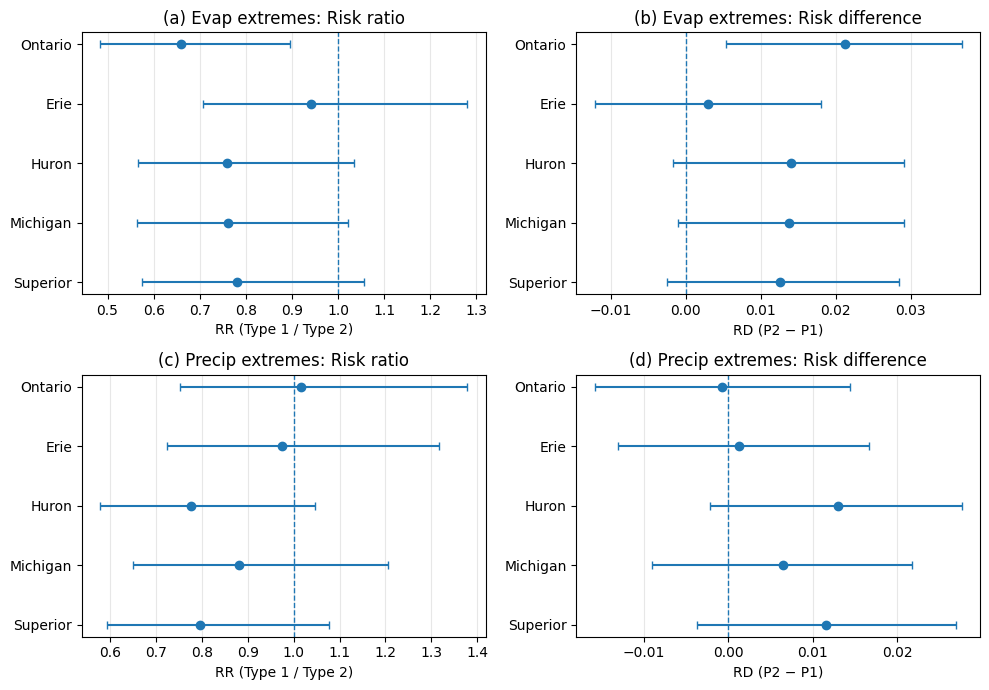

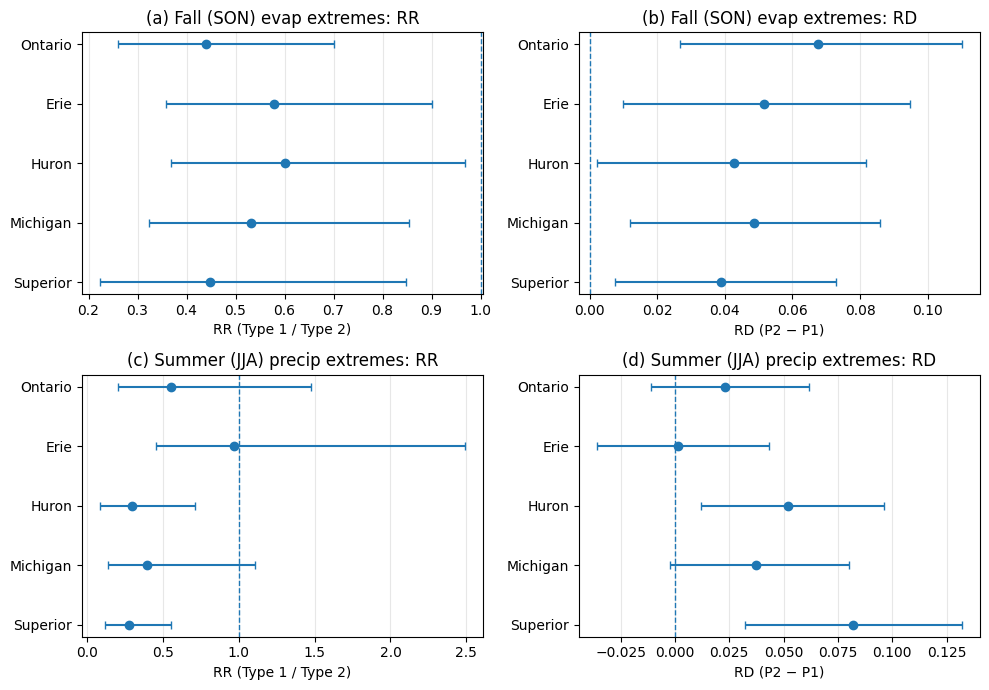

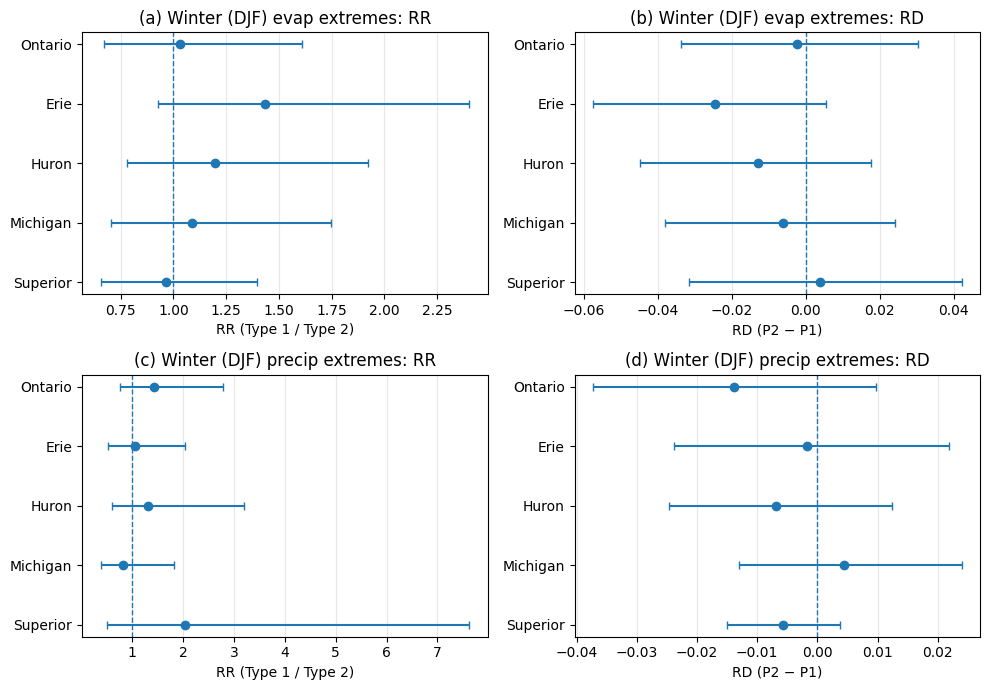

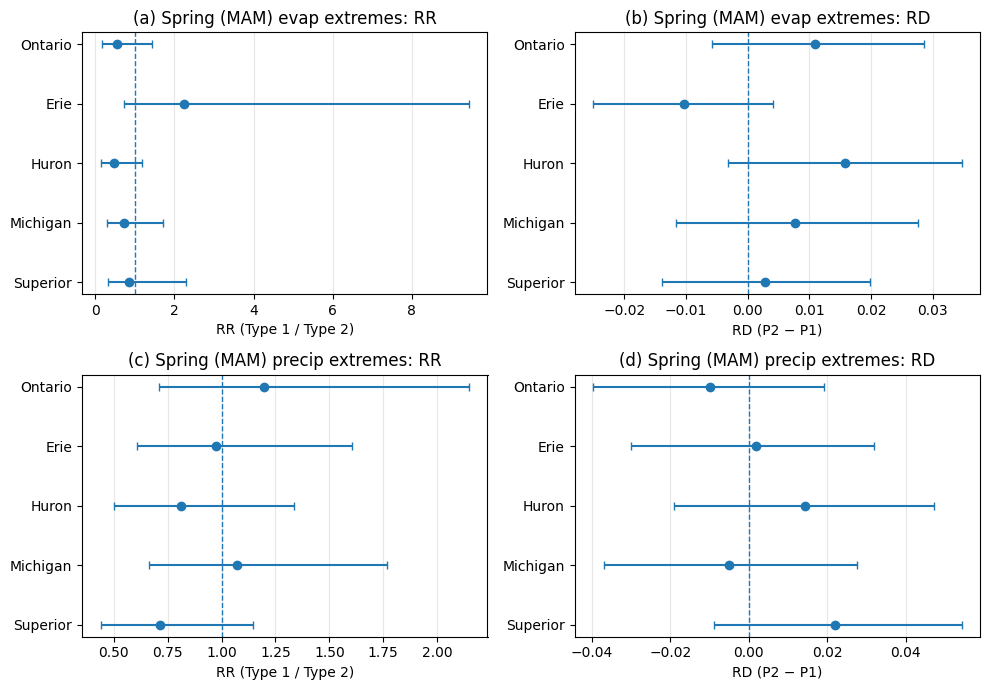

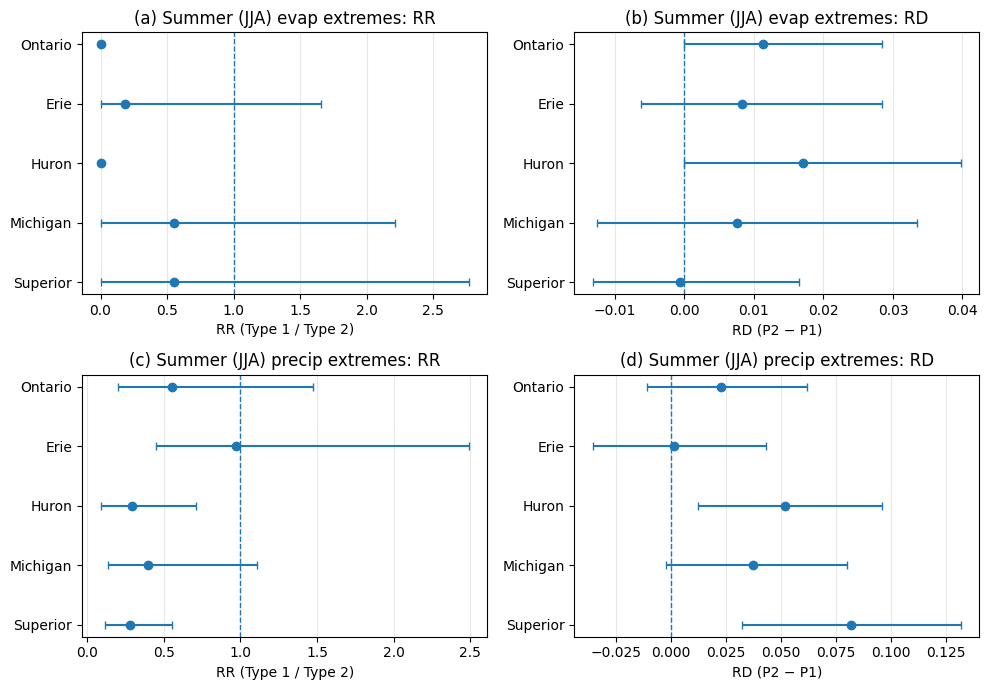

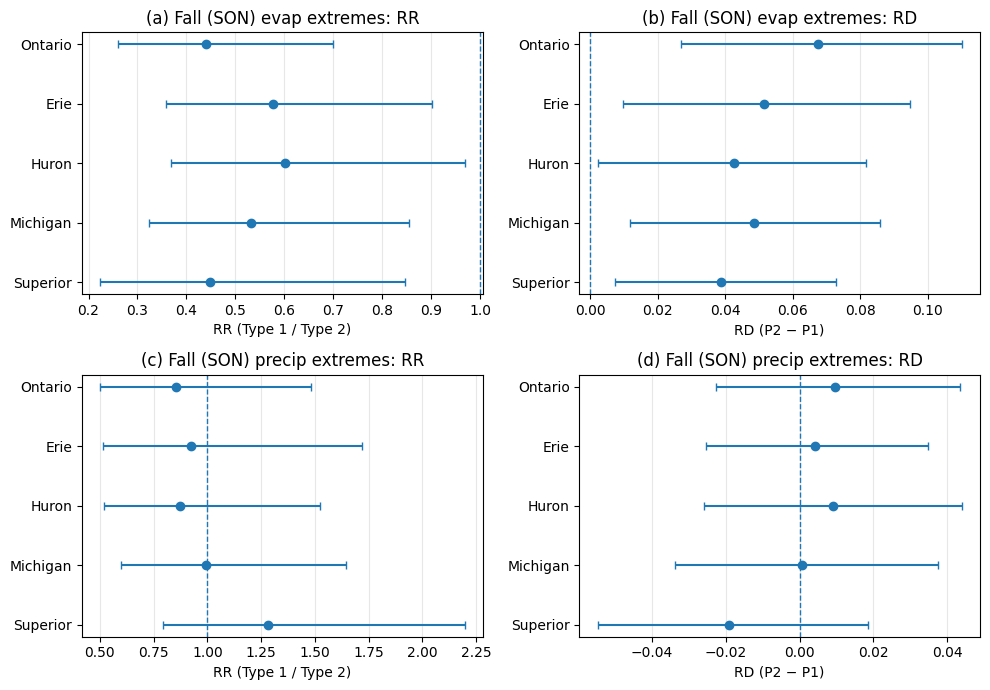

In [6]:

# ============================================================
# 4) Plotting helpers (forest) + figures
# ============================================================

def prep_for_plot(rr_df: pd.DataFrame, impact: str, season: str | None = None) -> pd.DataFrame:
    d = rr_df[rr_df["impact"] == impact].copy()
    if season is not None:
        d = d[d["season"] == season].copy()
    d["lake"] = d["lake"].astype(str).str.lower()
    d = d[d["lake"].isin(LAKE_ORDER)]
    d["lake_label"] = d["lake"].map(LAKE_LABELS)
    d["lake"] = pd.Categorical(d["lake"], categories=LAKE_ORDER, ordered=True)
    return d.sort_values("lake").reset_index(drop=True)

def forest(ax, d: pd.DataFrame, metric: str, title: str, xlabel: str, ref_value: float | None = None):
    if d.empty:
        ax.set_title(title); ax.set_xlabel(xlabel)
        ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes, alpha=0.7)
        ax.set_yticks([])
        if ref_value is not None:
            ax.axvline(ref_value, linestyle="--", linewidth=1)
        ax.grid(True, axis="x", alpha=0.3)
        return

    y = np.arange(len(d))
    med = d[f"{metric}_median"].to_numpy()
    low = d[f"{metric}_low"].to_numpy()
    high = d[f"{metric}_high"].to_numpy()
    xerr = np.vstack([med - low, high - med])

    ax.errorbar(med, y, xerr=xerr, fmt="o", capsize=3)
    if ref_value is not None:
        ax.axvline(ref_value, linestyle="--", linewidth=1)

    ax.set_yticks(y)
    ax.set_yticklabels(d["lake_label"])
    ax.invert_yaxis()
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.grid(True, axis="x", alpha=0.3)

def plot_all_seasons_2x2(rr_df_all: pd.DataFrame):
    d_evap   = prep_for_plot(rr_df_all, "evap")
    d_precip = prep_for_plot(rr_df_all, "precip")

    fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharey=True)

    forest(axes[0, 0], d_evap,   "rr", "(a) Evap extremes: Risk ratio",       "RR (Type 1 / Type 2)", 1.0)
    forest(axes[0, 1], d_evap,   "rd", "(b) Evap extremes: Risk difference",  "RD (P2 − P1)",          0.0)
    forest(axes[1, 0], d_precip, "rr", "(c) Precip extremes: Risk ratio",     "RR (Type 1 / Type 2)", 1.0)
    forest(axes[1, 1], d_precip, "rd", "(d) Precip extremes: Risk difference","RD (P2 − P1)",          0.0)

    for ax in axes[:, 1]:
        ax.tick_params(labelleft=True)
    plt.tight_layout()
    return fig, axes

def plot_takehome_son_evap_jja_precip(rr_df_seasons: pd.DataFrame):
    d_evap_son   = prep_for_plot(rr_df_seasons, "evap",   season="SON")
    d_precip_jja = prep_for_plot(rr_df_seasons, "precip", season="JJA")

    fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharey=True)

    forest(axes[0, 0], d_evap_son,   "rr", "(a) Fall (SON) evap extremes: RR", "RR (Type 1 / Type 2)", 1.0)
    forest(axes[0, 1], d_evap_son,   "rd", "(b) Fall (SON) evap extremes: RD", "RD (P2 − P1)",          0.0)
    forest(axes[1, 0], d_precip_jja, "rr", "(c) Summer (JJA) precip extremes: RR", "RR (Type 1 / Type 2)", 1.0)
    forest(axes[1, 1], d_precip_jja, "rd", "(d) Summer (JJA) precip extremes: RD", "RD (P2 − P1)",          0.0)

    for ax in axes[:, 1]:
        ax.tick_params(labelleft=True)
    plt.tight_layout()
    return fig, axes

def plot_season_2x2(rr_df_seasons: pd.DataFrame, season: str):
    d_evap   = prep_for_plot(rr_df_seasons, "evap",   season=season)
    d_precip = prep_for_plot(rr_df_seasons, "precip", season=season)

    fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharey=True)
    lab = SEASON_TITLES.get(season, season)

    forest(axes[0, 0], d_evap,   "rr", f"(a) {lab} evap extremes: RR",   "RR (Type 1 / Type 2)", 1.0)
    forest(axes[0, 1], d_evap,   "rd", f"(b) {lab} evap extremes: RD",   "RD (P2 − P1)",          0.0)
    forest(axes[1, 0], d_precip, "rr", f"(c) {lab} precip extremes: RR", "RR (Type 1 / Type 2)", 1.0)
    forest(axes[1, 1], d_precip, "rd", f"(d) {lab} precip extremes: RD", "RD (P2 − P1)",          0.0)

    for ax in axes[:, 1]:
        ax.tick_params(labelleft=True)
    plt.tight_layout()
    return fig, axes


# Make the key figures
plot_all_seasons_2x2(rr_df_all)
plt.show()

plot_takehome_son_evap_jja_precip(rr_df_seasons)
plt.show()

# Optional: one per season
for s in SEASON_ORDER:
     plot_season_2x2(rr_df_seasons, s)
     plt.show()


storm_type,Type 1 (early-life-cycle),Type 2 (late-life-cycle)
season,,
DJF,597,455
MAM,518,445
JJA,318,176
SON,470,337


storm_type,Type 1 (early-life-cycle),Type 2 (late-life-cycle)
season,,
DJF,0.313715,0.322010
MAM,0.272202,0.314933
JJA,0.167105,0.124558
SON,0.246978,0.238500


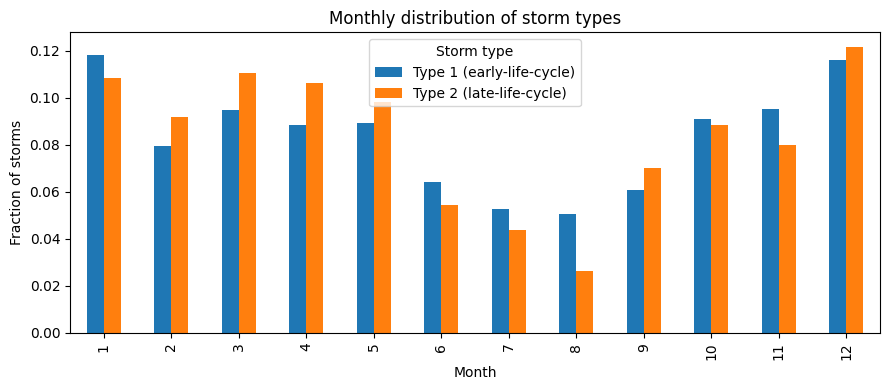

In [7]:


# ============================================================
# 5) Diagnostics at the bottom (counts + monthly distribution)
# ============================================================

# Counts by season and type
season_counts = (
    df.groupby(["season", "storm_type"]).size().unstack("storm_type").reindex(SEASON_ORDER)
)
display(season_counts)

season_frac = season_counts.div(season_counts.sum(axis=0), axis=1)
display(season_frac)

# Monthly distribution (fractions by type)
month_counts = df.groupby(["month", "storm_type"]).size().unstack("storm_type").sort_index()
month_frac = month_counts.div(month_counts.sum(axis=0), axis=1)

ax = month_frac.plot(kind="bar", figsize=(9, 4))
ax.set_ylabel("Fraction of storms")
ax.set_xlabel("Month")
ax.set_title("Monthly distribution of storm types")
ax.legend(title="Storm type")
plt.tight_layout()
plt.show()


In [8]:
# ============================================================
# 6) Save figure-ready outputs (NO recomputation required)
# ============================================================

import os

OUTDIR = "../processed"
os.makedirs(OUTDIR, exist_ok=True)

# --- Core figure tables ---
rr_df_all.to_csv(os.path.join(OUTDIR, "rr_df_all_seasons.csv"), index=False)
rr_df_seasons.to_csv(os.path.join(OUTDIR, "rr_df_by_season.csv"), index=False)

# --- Thresholds used to define extremes (for provenance) ---
pd.Series(precip_thresh, name="precip_95th").to_csv(
    os.path.join(OUTDIR, "precip_extreme_thresholds.csv")
)
pd.Series(evap_thresh, name="evap_05th").to_csv(
    os.path.join(OUTDIR, "evap_extreme_thresholds.csv")
)

# --- Diagnostics: counts (used for sanity / appendix figs) ---
season_counts.to_csv(
    os.path.join(OUTDIR, "storm_counts_by_season_and_type.csv")
)
season_frac.to_csv(
    os.path.join(OUTDIR, "storm_fraction_by_season_and_type.csv")
)

month_counts.to_csv(
    os.path.join(OUTDIR, "storm_counts_by_month_and_type.csv")
)
month_frac.to_csv(
    os.path.join(OUTDIR, "storm_fraction_by_month_and_type.csv")
)

print("Saved processed outputs for figure reproduction to ../processed/")


Saved processed outputs for figure reproduction to ../processed/
